# Machine Learning Tutorial: hands-on with JAX

Tutorial for the lecture series *Machine Learning for Physicists*.

In a previous tutorial ([01_tutorial_CurveFitting.ipynb](01_tutorial_CurveFitting.ipynb)) you fitted a function with hand-coded gradients in NumPy. In this notebook you will repeat that exercise, but now using **JAX** to compute the gradients automatically.

The notebook is split in two parts:

- **Part 1** &mdash; a short refresher on `jax.grad` and gradient-based optimization (using `optax`) on a toy function.
- **Part 2** &mdash; using JAX to fit a parameterized function, repeating the examples of the previous tutorial.

---
## Part 1: A quick reminder on JAX

JAX behaves much like NumPy, but on top it gives you:

- **`jax.grad`** &mdash; automatic differentiation of any Python function that returns a scalar.
- **`jax.jit`** &mdash; just-in-time compilation (we will not need it here).
- A growing ecosystem of libraries; we will use **`optax`** for the optimizers.

##### Imports

In [2]:
import jax
import jax.numpy as jnp
import optax

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

##### A toy function with a known minimum

We consider a simple two-parameter function

$$ f(\theta) = (\theta_0 - 1)^2 + 4\,(\theta_1 + 2)^2 $$

with the obvious minimum at $\theta^\star = (1, -2)$. The two directions have different curvatures, so the level sets are elongated ellipses &mdash; a good situation to compare optimizers.

In [3]:
def f(theta):
    return (theta[0] - 1.0)**2 + 4.0 * (theta[1] + 2.0)**2

theta_star = jnp.array([1.0, -2.0])

Visualize the loss landscape.

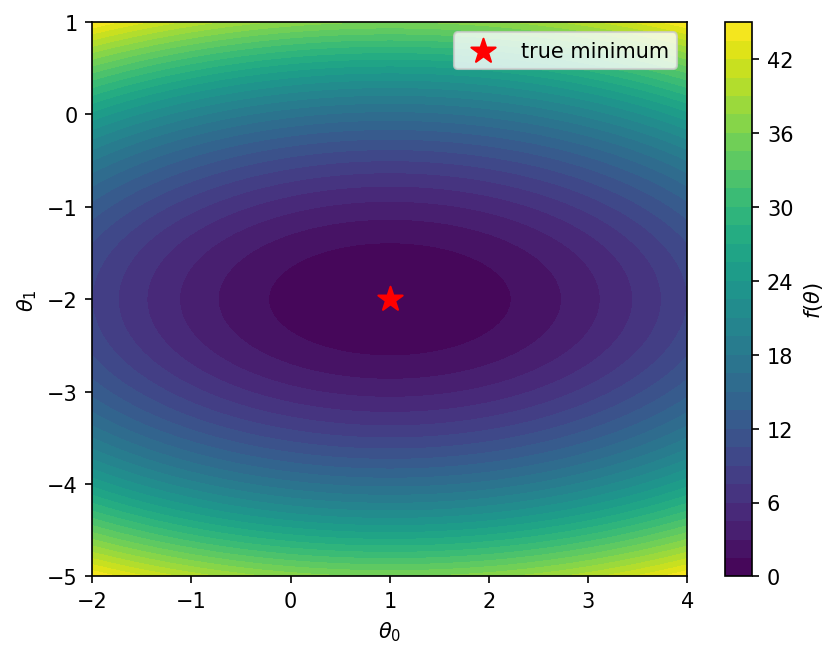

In [4]:
t0 = jnp.linspace(-2.0, 4.0, 100)
t1 = jnp.linspace(-5.0, 1.0, 100)
T0, T1 = jnp.meshgrid(t0, t1, indexing='ij')
Z = (T0 - 1.0)**2 + 4.0 * (T1 + 2.0)**2

plt.contourf(T0, T1, Z, 30)
plt.colorbar(label=r'$f(\theta)$')
plt.scatter([theta_star[0]], [theta_star[1]], marker='*', color='red', s=150, label='true minimum')
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.legend()
plt.show()

##### Computing the gradient with `jax.grad`

`jax.grad(f)` returns a *new function* that, when called on $\theta$, gives $\nabla_\theta f(\theta)$. By default the gradient is taken with respect to the first argument.

For our toy function the analytical gradient is

$$ \nabla_\theta f(\theta) = \big(\,2(\theta_0 - 1),\; 8(\theta_1 + 2)\,\big). $$

Let us verify that JAX gets the same result.

In [5]:
# the function grad_f will calculate the gradient of f via automatic differentiation
grad_f = jax.grad(f)

# for comparison, we have implemented the analytical expression for the gradient
def grad_f_analytic(theta):
    return jnp.array([2.0 * (theta[0] - 1.0), 8.0 * (theta[1] + 2.0)])

for theta_test in [jnp.array([0.0, 0.0]),
                   jnp.array([3.0, -1.0]),
                   jnp.array([-1.5, 2.5])]:
    print(f"theta = {theta_test}")
    print(f"   jax.grad  : {grad_f(theta_test)}")
    print(f"   analytical: {grad_f_analytic(theta_test)}")

theta = [0. 0.]
   jax.grad  : [-2. 16.]
   analytical: [-2. 16.]
theta = [ 3. -1.]
   jax.grad  : [4. 8.]
   analytical: [4. 8.]
theta = [-1.5  2.5]
   jax.grad  : [-5. 36.]
   analytical: [-5. 36.]


##### Gradient descent with `optax`

The simplest update rule, stochastic gradient descent (SGD), reads

$$ \theta^{(n+1)} = \theta^{(n)} - \eta \, \nabla_\theta f(\theta^{(n)}). $$

In practice we rarely implement this rule by hand. **`optax`** provides a large collection of optimizers (SGD, Adam, RMSProp, ...) behind a common interface. The workflow is always the same:

1. create the optimizer,
2. initialize its state with the current parameters,
3. in the loop: compute the gradient, ask the optimizer for an update, apply it.

Below you can switch between plain SGD and the popular Adam optimizer, which adapts the step size per parameter. Try both!

In [6]:
# Select an optimizer (try both!):
optimizer = optax.sgd(learning_rate=0.1)
# optimizer = optax.adam(learning_rate=0.1)

theta = jnp.array([-1.0, 0.5])     # arbitrary starting point
opt_state = optimizer.init(theta)
nsteps = 50

trajectory = [theta]
loss = [f(theta)]

for n in range(nsteps):
    grads = grad_f(theta)
    updates, opt_state = optimizer.update(grads, opt_state)
    theta = optax.apply_updates(theta, updates)
    trajectory.append(theta)
    loss.append(f(theta))

trajectory = jnp.array(trajectory)
loss = jnp.array(loss)

print(f"Final theta : {theta}")
print(f"True minimum: {theta_star}")

Final theta : [ 0.9999715 -2.       ]
True minimum: [ 1. -2.]


##### Visualize the optimization

Left: the trajectory on the loss landscape. Right: the loss as a function of the optimization step (log scale).

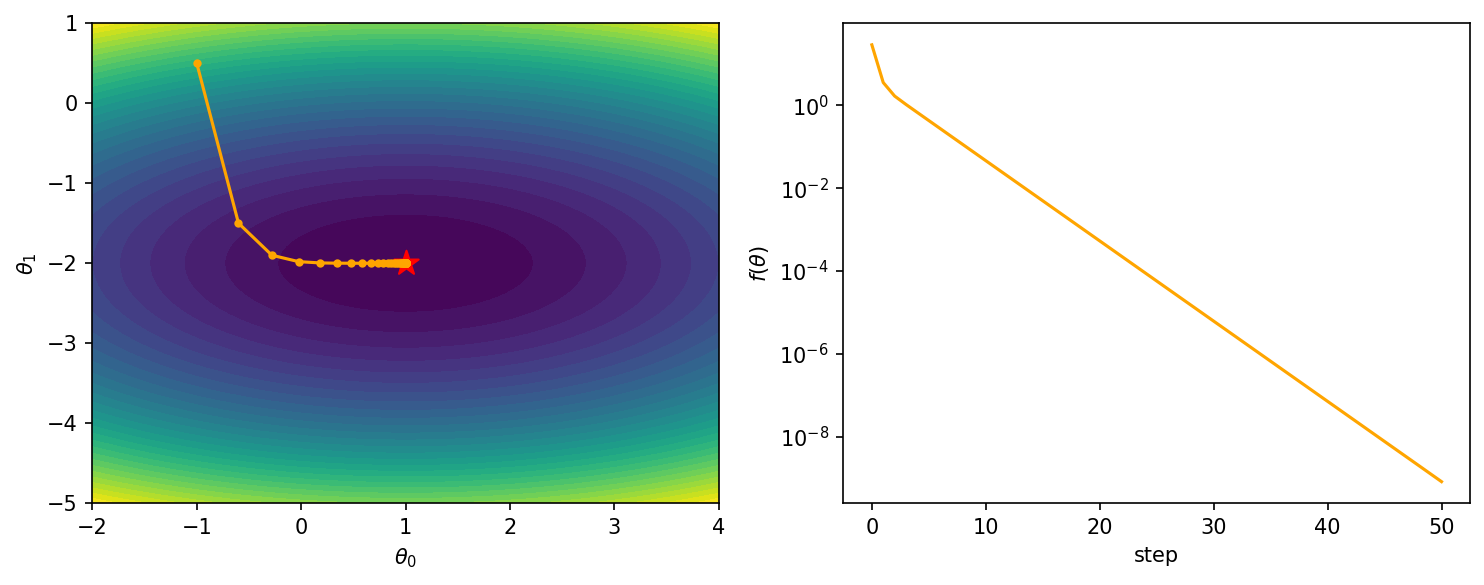

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4))

ax[0].contourf(T0, T1, Z, 30)
ax[0].plot(trajectory[:, 0], trajectory[:, 1], 'o-', color='orange', markersize=3)
ax[0].scatter([theta_star[0]], [theta_star[1]], marker='*', color='red', s=150)
ax[0].set_xlabel(r'$\theta_0$')
ax[0].set_ylabel(r'$\theta_1$')

ax[1].semilogy(loss, color='orange')
ax[1].set_xlabel('step')
ax[1].set_ylabel(r'$f(\theta)$')

plt.tight_layout()
plt.show()

---
## Part 2: Function fitting with JAX

We now turn to the curve-fitting problem from [01_tutorial_CurveFitting.ipynb](01_tutorial_CurveFitting.ipynb): given a target function $f_{\text{true}}(x)$, find the parameters $\theta$ of a model $f(x; \theta)$ that best reproduce it. In the previous tutorial you computed the gradient of the cost analytically. Here we let **`jax.grad`** do that for us &mdash; the workflow becomes nearly independent of the specific shape of $f$.

### Example 1: a Lorentzian-like target

We start with the same example as in the previous tutorial:

$$ f_{\text{true}}(x) = \frac{3}{(x - 0.5)^2 + 1}, \qquad f(x; \theta) = \frac{\theta_0}{(x - \theta_1)^2 + 1}. $$

The target parameters are $\theta^\star = (3, 0.5)$.

In [8]:
def true_f(x):
    return 3.0 / ((x - 0.5)**2 + 1.0)

def f(theta, x):
    return theta[0] / ((x - theta[1])**2 + 1.0)

##### The cost function and its gradient

We use the mean squared error on a batch of $x$ values:

$$ C(\theta, x) = \tfrac{1}{2} \langle (f(x; \theta) - f_{\text{true}}(x))^2 \rangle_x. $$

In the previous tutorial you had to compute $\nabla_\theta C$ by hand. With JAX we simply call `jax.grad` &mdash; autodiff handles every term, no matter how complicated $f$ becomes.

In [ ]:
def cost(theta, x):
    # todo: write the cost function
    pass

grad_cost = jax.grad(cost)  # gradient w.r.t. theta (the first argument)

##### Drawing random samples and plotting the starting state

The $x$ values are drawn from a Gaussian (standard deviation `width`). Below we compare the target (blue) with the model at an arbitrary starting $\theta$ (orange).

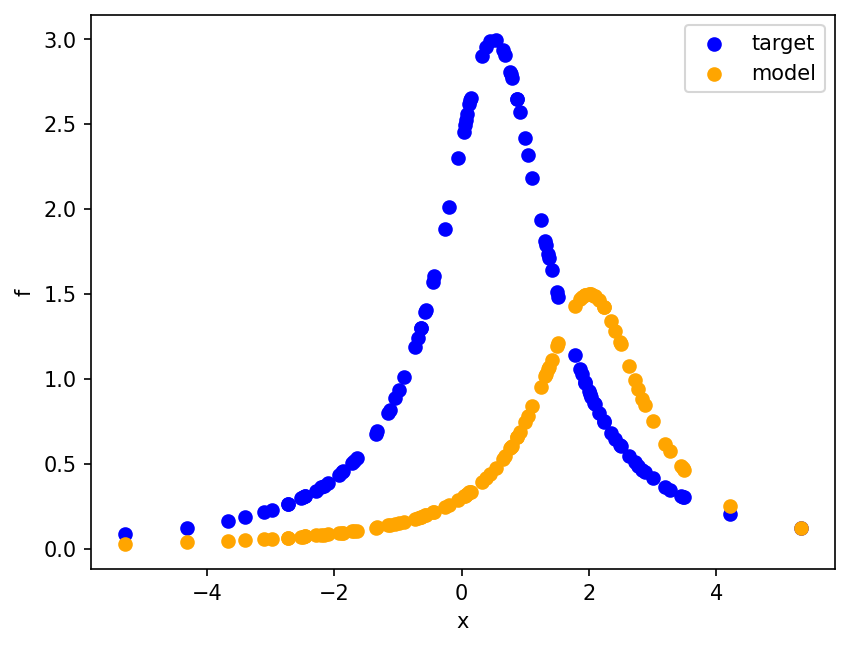

In [9]:
def samples(nsamples, width):
    return width * np.random.randn(nsamples)

theta = jnp.array([1.5, 2.0])  # arbitrary starting point
x = samples(100, 2.0)

plt.scatter(x, true_f(x), color='blue', label='target')
plt.scatter(x, f(theta, x), color='orange', label='model')
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.show()

##### The cost landscape

We evaluate the cost on a grid of $(\theta_0, \theta_1)$ to see where the minimum sits and how the loss surface is shaped.

##### Stochastic gradient descent with `optax`

The training loop has exactly the same structure as in Part 1. The only difference is that the gradient is now evaluated on a *fresh random batch of $x$ values* at every step &mdash; this is what makes the descent *stochastic*.

To keep the loss curve smooth we monitor the cost on a fixed, larger evaluation batch (`x_eval`).

In [ ]:
optimizer = optax.adam(learning_rate=0.1)
theta = jnp.array([1.5, 2.0])
opt_state = optimizer.init(theta)

nsteps = 500
nsamples = 10
xrange = 2.0

# example how to create a random sample
x_sample = samples(nsamples, xrange)  

# trajectory = [theta]
# losses = [cost(theta, x_eval)]

# todo: write an optimization loop to find the optimal parameters theta
# next: create two arrays. The array trajectories stores the sequence of thetas, the array losses stores the evolution of the average loss function for a fixed (and larger) set of datapoints
# These arrays are required for plotting


print(f'Final theta : {theta}')
print(f'Target theta: (3.0, 0.5)')

##### Visualising the result

Left: the optimization trajectory on the cost landscape. Middle: the cost as a function of step. Right: the fitted function compared with the target.

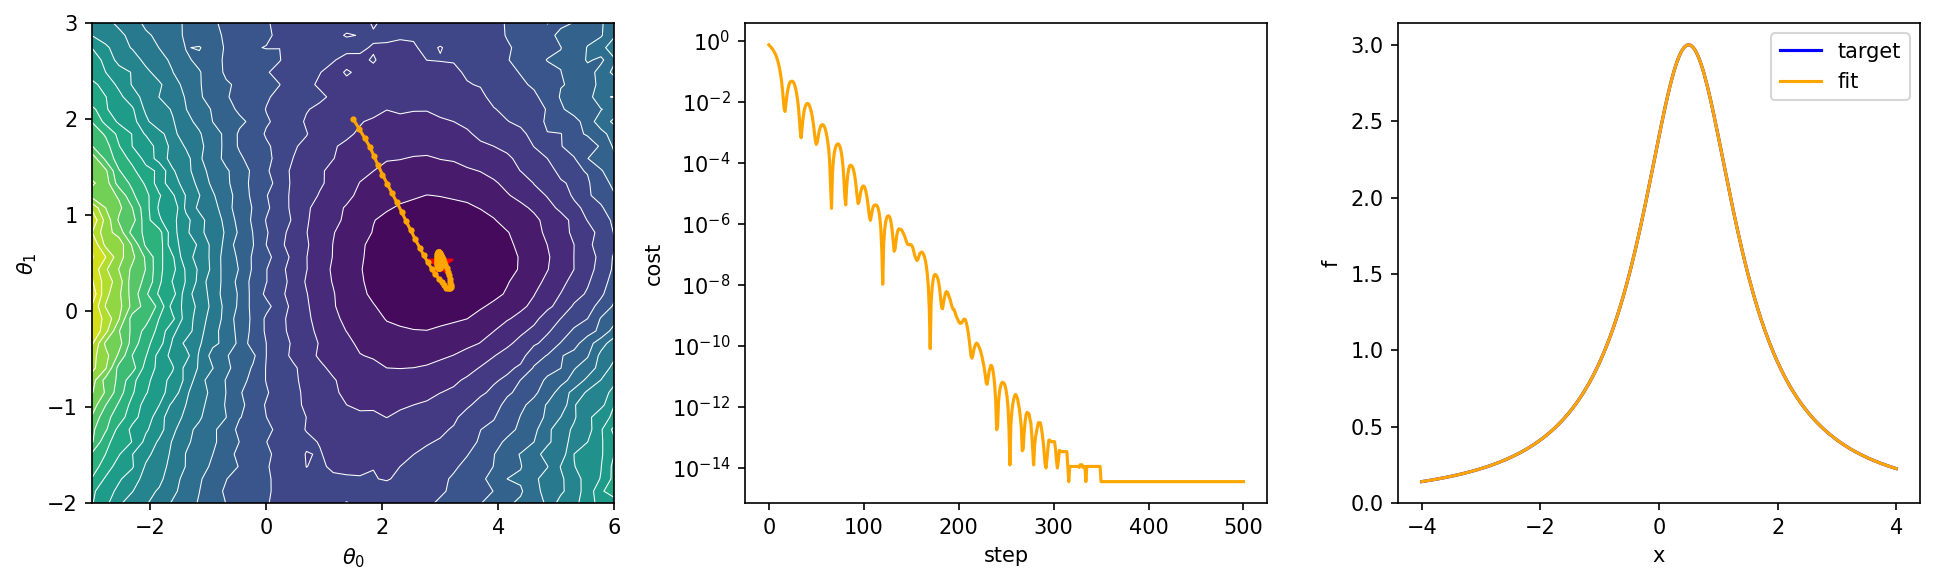

In [11]:
def cost_landscape(theta0s, theta1s, nsamples, width):
    C = np.zeros((len(theta0s), len(theta1s)))
    for j0 in range(len(theta0s)):
        for j1 in range(len(theta1s)):
            x = samples(nsamples, width)
            C[j0, j1] = cost(jnp.array([theta0s[j0], theta1s[j1]]), x)
    return C

theta0s = jnp.linspace(-3.0, 6.0, 40)
theta1s = jnp.linspace(-2.0, 3.0, 40)
C_grid = cost_landscape(theta0s, theta1s, 2000, 2.0)

T0, T1 = jnp.meshgrid(theta0s, theta1s, indexing='ij')

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(13, 4))

ax[0].contourf(T0, T1, C_grid, 20)
ax[0].contour(T0, T1, C_grid, 20, colors='white', linewidths=0.5)
ax[0].plot(trajectory[:, 0], trajectory[:, 1], 'o-', color='orange', markersize=2)
ax[0].scatter([3.0], [0.5], marker='*', color='red', s=150)
ax[0].set_xlabel(r'$\theta_0$')
ax[0].set_ylabel(r'$\theta_1$')

ax[1].semilogy(losses, color='orange')
ax[1].set_xlabel('step')
ax[1].set_ylabel('cost')

x_sweep = jnp.linspace(-4.0, 4.0, 300)
ax[2].plot(x_sweep, true_f(x_sweep), color='blue', label='target')
ax[2].plot(x_sweep, f(theta, x_sweep), color='orange', label='fit')
ax[2].set_xlabel('x')
ax[2].set_ylabel('f')
ax[2].legend()

plt.tight_layout()
plt.show()

### Example 2: a sinusoidal target

We change the target to $f_{\text{true}}(x) = \sin(5x + 1)$ and the model to $f(x; \theta) = \sin(\theta_0 x + \theta_1)$, with target parameters $\theta^\star = (5, 1)$.

In [ ]:
# todo: repeat the same as above for the new function

### Example 3: a three-parameter Lorentzian

Finally we add a third parameter to the Lorentzian model,

$$ f(x; \theta) = \frac{\theta_0}{(x - \theta_1)^2 + \theta_2}, $$

keeping the target $f_{\text{true}}(x) = 3 / ((x - 0.5)^2 + 1)$, so $\theta^\star = (3, 0.5, 1)$.

In [ ]:
# todo: repeat the same as above for the new function

In [10]:
# Bonus tasks:
# - Make the run more efficient! Use jax.jit to compile the code
# - use jax.vmap to parallelize the execution of code